# Load Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os, warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    roc_auc_score, f1_score, classification_report
)

os.makedirs("outputs", exist_ok=True)

# Rebuild Test Set

In [2]:
orders   = pd.read_csv("data/raw/olist_orders_dataset.csv", parse_dates=[
               "order_purchase_timestamp","order_delivered_customer_date"])
reviews  = pd.read_csv("data/raw/olist_order_reviews_dataset.csv",
               parse_dates=["review_creation_date"])
items    = pd.read_csv("data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("data/raw/olist_order_payments_dataset.csv")
customers= pd.read_csv("data/raw/olist_customers_dataset.csv")
products = pd.read_csv("data/raw/olist_products_dataset.csv")
cat_map  = pd.read_csv("data/raw/product_category_name_translation.csv")
cust_feats = pd.read_parquet("data/features/customer_features_clustered.parquet")

products = products.merge(cat_map, on="product_category_name", how="left")

rev = (reviews.sort_values("review_score")
       .drop_duplicates("order_id", keep="first")
       [["order_id","review_score","review_creation_date"]])
pay = (payments.groupby("order_id")
       .agg(total_value=("payment_value","sum"),
            payment_type=("payment_type","first"))
       .reset_index())

df = (orders
      .merge(customers[["customer_id","customer_unique_id","customer_state"]],
             on="customer_id", how="left")
      .merge(rev,  on="order_id", how="left")
      .merge(pay,  on="order_id", how="left"))

df["is_return"] = (
    (df["order_status"] == "delivered") & (df["review_score"] <= 2)
).astype(int)

# Tenure
first_order = (df.groupby("customer_unique_id")["order_purchase_timestamp"]
               .min().rename("first_order_date").reset_index())
df = df.merge(first_order, on="customer_unique_id", how="left")
df["customer_tenure_days"] = (
    df["order_purchase_timestamp"] - df["first_order_date"]
).dt.days.fillna(0)

# Seller return rate
order_seller = (items[["order_id","seller_id"]].drop_duplicates("order_id")
    .merge(df[["order_id","is_return"]], on="order_id", how="left"))
seller_rate = (order_seller.groupby("seller_id")["is_return"]
               .mean().rename("seller_return_rate").reset_index())
df = df.merge(items[["order_id","seller_id"]].drop_duplicates("order_id"),
              on="order_id", how="left")
df = df.merge(seller_rate, on="seller_id", how="left")

# Category return rate
order_cat = (items[["order_id","product_id"]].drop_duplicates("order_id")
    .merge(products[["product_id","product_category_name"]], on="product_id", how="left")
    .merge(df[["order_id","is_return"]], on="order_id", how="left"))
cat_rate = (order_cat.groupby("product_category_name")["is_return"]
            .mean().rename("category_return_rate").reset_index())
df = df.merge(items[["order_id","product_id"]].drop_duplicates("order_id"),
              on="order_id", how="left")
df = df.merge(products[["product_id","product_category_name"]].drop_duplicates("product_id"),
              on="product_id", how="left")
df = df.merge(cat_rate, on="product_category_name", how="left")

le_pay = LabelEncoder()
df["payment_type_enc"] = le_pay.fit_transform(df["payment_type"].fillna("unknown"))

# Merge cluster features
cluster_cols_to_add = [c for c in cust_feats.columns
                       if c not in ["total_orders","total_returns","customer_unique_id"]]
df = df.merge(cust_feats[["customer_unique_id"] + cluster_cols_to_add],
              on="customer_unique_id", how="left")
cluster_dummies = pd.get_dummies(df["cluster_hier"], prefix="cluster").astype(int)
df = pd.concat([df, cluster_dummies], axis=1)

model_df = df[df["order_status"] == "delivered"].dropna(subset=["total_value"]).copy()
split_date = model_df["order_purchase_timestamp"].quantile(0.80)
test = model_df[model_df["order_purchase_timestamp"] > split_date].copy()

# Load feature column lists
feature_cols = joblib.load("outputs/feature_cols.pkl")
TXN_COLS = feature_cols["txn"]
ALL_COLS  = feature_cols["all"]

# Guard: align columns to what the model was trained on
X_test_A = test[[c for c in TXN_COLS if c in test.columns]].fillna(0)
X_test_B = test[[c for c in ALL_COLS  if c in test.columns]].fillna(0)
y_test   = test["is_return"]

model_A = joblib.load("outputs/model_A.pkl")
model_B = joblib.load("outputs/model_B.pkl")

proba_A = model_A.predict_proba(X_test_A)[:,1]
proba_B = model_B.predict_proba(X_test_B)[:,1]

print(f"Test set: {len(test):,} orders  |  Return rate: {y_test.mean()*100:.2f}%")

Test set: 19,296 orders  |  Return rate: 9.64%


# PLOT 1 — Precision-Recall curves

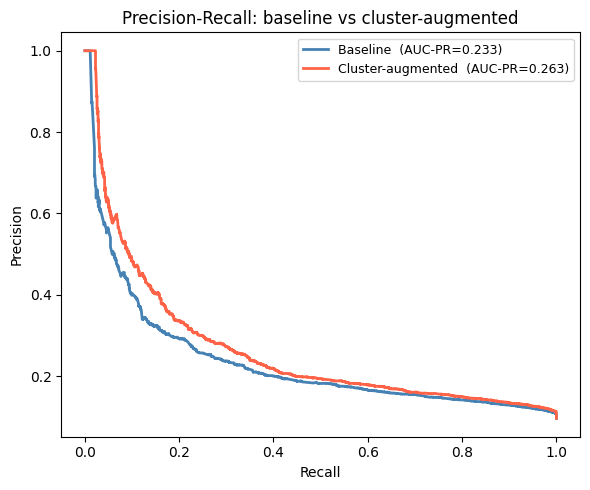

  AUC-PR  A=0.2333  B=0.2632  improvement=12.8%


In [3]:
aucpr_A = average_precision_score(y_test, proba_A)
aucpr_B = average_precision_score(y_test, proba_B)

fig, ax = plt.subplots(figsize=(6, 5))
for proba, label, color in [
        (proba_A, f"Baseline  (AUC-PR={aucpr_A:.3f})", "steelblue"),
        (proba_B, f"Cluster-augmented  (AUC-PR={aucpr_B:.3f})", "tomato")]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ax.plot(r, p, label=label, linewidth=2, color=color)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall: baseline vs cluster-augmented")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/eval_pr_curve.png", dpi=150)
plt.show()
print(f"  AUC-PR  A={aucpr_A:.4f}  B={aucpr_B:.4f}  improvement={((aucpr_B-aucpr_A)/aucpr_A)*100:.1f}%")

# PLOT 2 — Lift at each decile

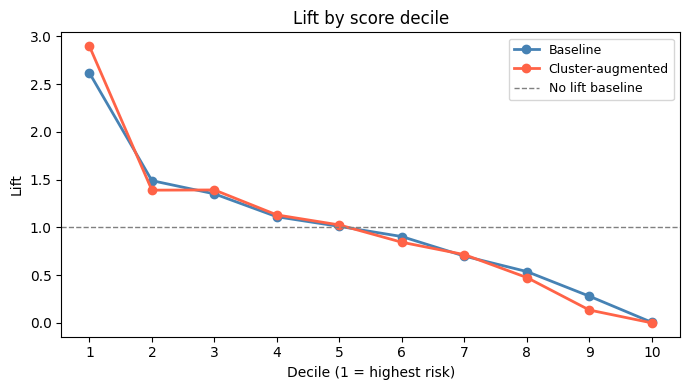

  Lift @ top decile — Baseline: 2.62x
  Lift @ top decile — Cluster-aug: 2.90x


In [4]:
results = pd.DataFrame({"y": y_test.values, "A": proba_A, "B": proba_B})
overall = results["y"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
for col, color, label in [("A", "steelblue", "Baseline"),
                            ("B", "tomato",    "Cluster-augmented")]:
    results["decile"] = pd.qcut(results[col], 10, labels=False, duplicates="drop")
    lift = (results.groupby("decile")["y"].mean() / overall).sort_index(ascending=False)
    ax.plot(range(1, len(lift)+1), lift.values, "o-", color=color, label=label, linewidth=2)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="No lift baseline")
ax.set_xlabel("Decile (1 = highest risk)")
ax.set_ylabel("Lift")
ax.set_title("Lift by score decile")
ax.legend(fontsize=9)
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.savefig("outputs/eval_lift.png", dpi=150)
plt.show()

# Top-decile lift numbers
for col, label in [("A","Baseline"), ("B","Cluster-aug")]:
    results["decile"] = pd.qcut(results[col], 10, labels=False, duplicates="drop")
    top = results[results["decile"] == 9]["y"].mean()
    print(f"  Lift @ top decile — {label}: {top/overall:.2f}x")

# PLOT 3 — SHAP feature importance (Model B)

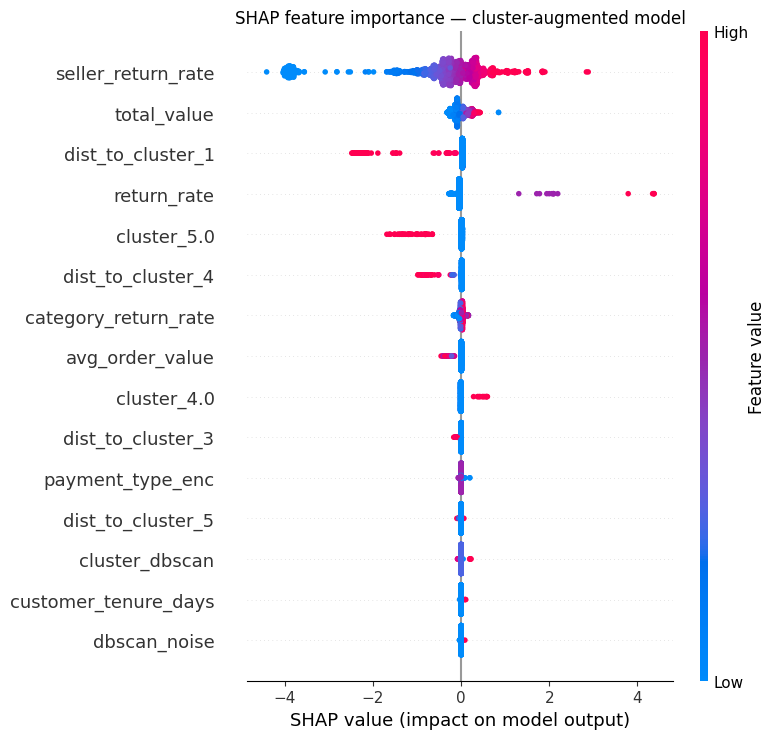

  Cluster features in top 10 SHAP: ['dist_to_cluster_1', 'cluster_5.0', 'dist_to_cluster_4', 'cluster_4.0', 'dist_to_cluster_3']


In [5]:
try:
    import shap
    sample_idx = np.random.default_rng(42).choice(len(X_test_B), size=min(2000, len(X_test_B)), replace=False)
    X_shap = X_test_B.iloc[sample_idx]

    explainer   = shap.TreeExplainer(model_B)
    shap_values = explainer.shap_values(X_shap)

    fig, ax = plt.subplots(figsize=(8, 6))
    shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
    plt.title("SHAP feature importance — cluster-augmented model")
    plt.tight_layout()
    plt.savefig("outputs/eval_shap.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Which cluster features rank in top 10?
    mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test_B.columns)
    top10 = mean_abs_shap.sort_values(ascending=False).head(10)
    cluster_in_top10 = [f for f in top10.index if "cluster" in f or "dist_to" in f]
    print(f"  Cluster features in top 10 SHAP: {cluster_in_top10}")
except ImportError:
    print("  shap not installed — run: pip install shap")

# PLOT 4 — Cluster profiles bar chart

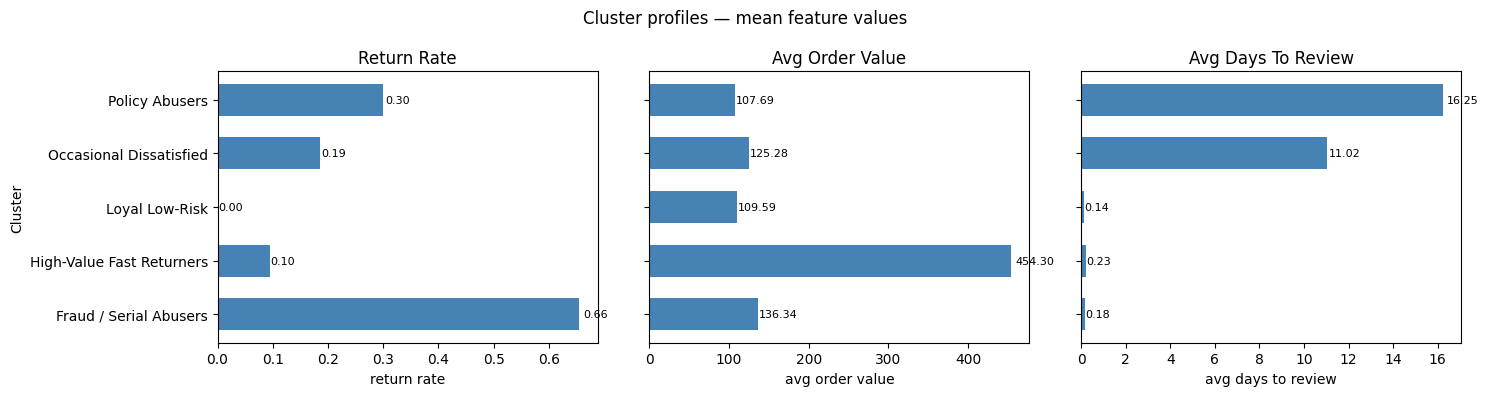

In [6]:
profile_cols = ["return_rate", "avg_order_value", "avg_days_to_review"]
profile_cols = [c for c in profile_cols if c in cust_feats.columns]

profiles = (cust_feats
    .groupby("cluster_name")[profile_cols]
    .mean()
    .reset_index())

fig, axes = plt.subplots(1, len(profile_cols), figsize=(5 * len(profile_cols), 4), sharey=True)
if len(profile_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, profile_cols):
    ax.barh(profiles["cluster_name"], profiles[col], color="steelblue", height=0.6)
    ax.set_xlabel(col.replace("_", " "))
    ax.set_title(col.replace("_", " ").title())
    for i, val in enumerate(profiles[col]):
        ax.text(val * 1.01, i, f"{val:.2f}", va="center", fontsize=8)

axes[0].set_ylabel("Cluster")
fig.suptitle("Cluster profiles — mean feature values", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/eval_cluster_profiles.png", dpi=150)
plt.show()

# Threshold Tuning — find F1-optimal threshold for Model B

In [7]:
p_arr, r_arr, thresh_arr = precision_recall_curve(y_test, proba_B)
f1_arr = np.where((p_arr + r_arr) == 0, 0, 2 * p_arr * r_arr / (p_arr + r_arr))
best_idx   = np.argmax(f1_arr)
best_thresh = thresh_arr[best_idx] if best_idx < len(thresh_arr) else 0.5
best_f1     = f1_arr[best_idx]
print(f"\n  Best F1={best_f1:.3f} at threshold={best_thresh:.3f}")

preds_B_tuned = (proba_B >= best_thresh).astype(int)
print(classification_report(y_test, preds_B_tuned, target_names=["Not returned","Returned"]))


  Best F1=0.290 at threshold=0.620
              precision    recall  f1-score   support

Not returned       0.93      0.89      0.91     17436
    Returned       0.25      0.34      0.29      1860

    accuracy                           0.84     19296
   macro avg       0.59      0.62      0.60     19296
weighted avg       0.86      0.84      0.85     19296



# Summary Text

In [8]:
roc_A = roc_auc_score(y_test, proba_A)
roc_B = roc_auc_score(y_test, proba_B)

summary = f"""
{'='*55}
EVALUATION SUMMARY
{'='*55}
Test set:          {len(test):,} orders
Return rate:       {y_test.mean()*100:.2f}%

               Baseline    Cluster-aug   Improvement
AUC-PR:        {aucpr_A:.4f}      {aucpr_B:.4f}       +{(aucpr_B-aucpr_A)/aucpr_A*100:.1f}%
AUC-ROC:       {roc_A:.4f}      {roc_B:.4f}       +{(roc_B-roc_A)/roc_A*100:.1f}%
Best F1 (B):   —             {best_f1:.4f}       (thresh={best_thresh:.2f})

Cluster features in top-10 SHAP: {cluster_in_top10 if 'cluster_in_top10' in dir() else 'run with shap installed'}

Outputs saved to outputs/
{'='*55}
"""
print(summary)
with open("outputs/eval_summary.txt", "w") as f:
    f.write(summary)
print("Saved: outputs/eval_summary.txt")


EVALUATION SUMMARY
Test set:          19,296 orders
Return rate:       9.64%

               Baseline    Cluster-aug   Improvement
AUC-PR:        0.2333      0.2632       +12.8%
AUC-ROC:       0.7111      0.7314       +2.8%
Best F1 (B):   —             0.2899       (thresh=0.62)

Cluster features in top-10 SHAP: ['dist_to_cluster_1', 'cluster_5.0', 'dist_to_cluster_4', 'cluster_4.0', 'dist_to_cluster_3']

Outputs saved to outputs/

Saved: outputs/eval_summary.txt
